In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# SciPy 2016 Scikit-learn Tutorial

Training and Testing Data
=====================================

To evaluate how well our supervised models generalize, we can split our data into a training and a test set:

<img src="figures/train_test_split_matrix.svg" width="100%">

In [2]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris()
X, y = iris.data, iris.target

classifier = KNeighborsClassifier()

Thinking about how machine learning is normally performed, the idea of a train/test split makes sense. Real world systems train on the data they have, and as other data comes in (from customers, sensors, or other sources) the classifier that was trained must predict on fundamentally *new* data. We can simulate this during training using a train/test split - the test data is a simulation of "future data" which will come into the system during production. 

Specifically for iris, the 150 labels in iris are sorted, which means that if we split the data using a proportional split, this will result in fudamentally altered class distributions. For instance, if we'd perform a common 2/3 training data and 1/3 test data split, our training dataset will only consists of flower classes 0 and 1 (Setosa and Versicolor), and our test set will only contain samples with class label 2 (Virginica flowers).

Under the assumption that all samples are independent of each other (in contrast time series data), we want to **randomly shuffle the dataset before we split the dataset** as illustrated above.

In [3]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

Now we need to split the data into training and testing. Luckily, this is a common pattern in machine learning and scikit-learn has a pre-built function to split data into training and testing sets for you. Here, we use 50% of the data as training, and 50% testing. 80% and 20% is another common split, but there are no hard and fast rules. The most important thing is to fairly evaluate your system on data it *has not* seen during training!

In [4]:
from sklearn.model_selection import train_test_split

train_X, test_X, train_y, test_y = train_test_split(X, y, 
                                                    train_size=0.5, 
                                                    random_state=123)
print("Labels for training and testing data")
print(train_y)
print(test_y)

Labels for training and testing data
[1 1 0 2 2 0 0 1 1 2 0 0 1 0 1 2 0 2 0 0 1 0 0 1 2 1 1 1 0 0 1 2 0 0 1 1 1
 2 1 1 1 2 0 0 1 2 2 2 2 0 1 0 1 1 0 1 2 1 2 2 0 1 0 2 2 1 1 2 2 1 0 1 1 2
 2]
[1 2 2 1 0 2 1 0 0 1 2 0 1 2 2 2 0 0 1 0 0 2 0 2 0 0 0 2 2 0 2 2 0 0 1 1 2
 0 0 1 1 0 2 2 2 2 2 1 0 0 2 0 0 1 1 1 1 2 1 2 0 2 1 0 0 2 1 2 2 0 1 1 2 0
 2]


---

**Tip: Stratified Split**

Especially for relatively small datasets, it's better to stratify the split. Stratification means that we maintain the original class proportion of the dataset in the test and training sets. For example, after we randomly split the dataset as shown in the previous code example, we have the following class proportions in percent:

In [5]:
print('All:', np.bincount(y) / float(len(y)) * 100.0)
print('Training:', np.bincount(train_y) / float(len(train_y)) * 100.0)
print('Test:', np.bincount(test_y) / float(len(test_y)) * 100.0)

All: [33.33333333 33.33333333 33.33333333]
Training: [30.66666667 40.         29.33333333]
Test: [36.         26.66666667 37.33333333]


So, in order to stratify the split, we can pass the label array as an additional option to the `train_test_split` function:

In [6]:
train_X, test_X, train_y, test_y = train_test_split(X, y, 
                                                    train_size=0.5, 
                                                    random_state=123,
                                                    stratify=y)

print('All:', np.bincount(y) / float(len(y)) * 100.0)
print('Training:', np.bincount(train_y) / float(len(train_y)) * 100.0)
print('Test:', np.bincount(test_y) / float(len(test_y)) * 100.0)

All: [33.33333333 33.33333333 33.33333333]
Training: [33.33333333 33.33333333 33.33333333]
Test: [33.33333333 33.33333333 33.33333333]


---

By evaluating our classifier performance on data that has been seen during training, we could get false confidence in the predictive power of our model. In the worst case, it may simply memorize the training samples but completely fails classifying new, similar samples -- we really don't want to put such a system into production!

Instead of using the same dataset for training and testing (this is called "resubstitution evaluation"), it is much much better to use a train/test split in order to estimate how well your trained model is doing on new data.

In [7]:
classifier.fit(train_X, train_y)
pred_y = classifier.predict(test_X)

print("Fraction Correct [Accuracy]:")
print(np.sum(pred_y == test_y) / float(len(test_y)))

Fraction Correct [Accuracy]:
0.96


We can also visualize the correct and failed predictions

In [8]:
print('Samples correctly classified:')
correct_idx = np.where(pred_y == test_y)[0]
print(correct_idx)

print('\nSamples incorrectly classified:')
incorrect_idx = np.where(pred_y != test_y)[0]
print(incorrect_idx)

Samples correctly classified:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 45 46 47 48
 50 51 52 53 54 55 56 57 58 59 61 62 63 64 65 66 67 68 69 70 71 72 73 74]

Samples incorrectly classified:
[44 49 60]


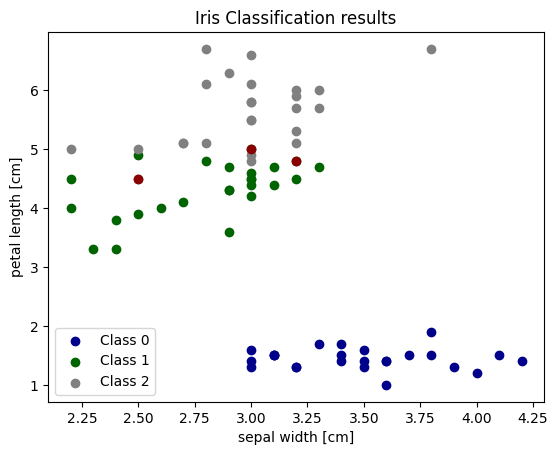

In [9]:
# Plot two dimensions

colors = ["darkblue", "darkgreen", "gray"]

for n, color in enumerate(colors):
    idx = np.where(test_y == n)[0]
    plt.scatter(test_X[idx, 1], test_X[idx, 2], color=color, label="Class %s" % str(n))

plt.scatter(test_X[incorrect_idx, 1], test_X[incorrect_idx, 2], color="darkred")

plt.xlabel('sepal width [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc=3)
plt.title("Iris Classification results")
plt.show()

We can see that the errors occur in the area where green (class 1) and gray (class 2) overlap. This gives us insight about what features to add - any feature which helps separate class 1 and class 2 should improve classifier performance.

# Exercise

Print the true labels of 3 wrong predictions and modify the scatterplot code, which we used above, to visualize and distinguish these three samples with different markers in the 2D scatterplot. Can you explain why our classifier made these wrong predictions?

Wrong predictions analysis:
Total wrong predictions: 3
Indices of wrong predictions: [44 49 60]

First 3 wrong predictions (indices): [44 49 60]
True labels vs Predicted labels:
Sample 44: True=1, Predicted=2
Sample 49: True=1, Predicted=2
Sample 60: True=2, Predicted=1


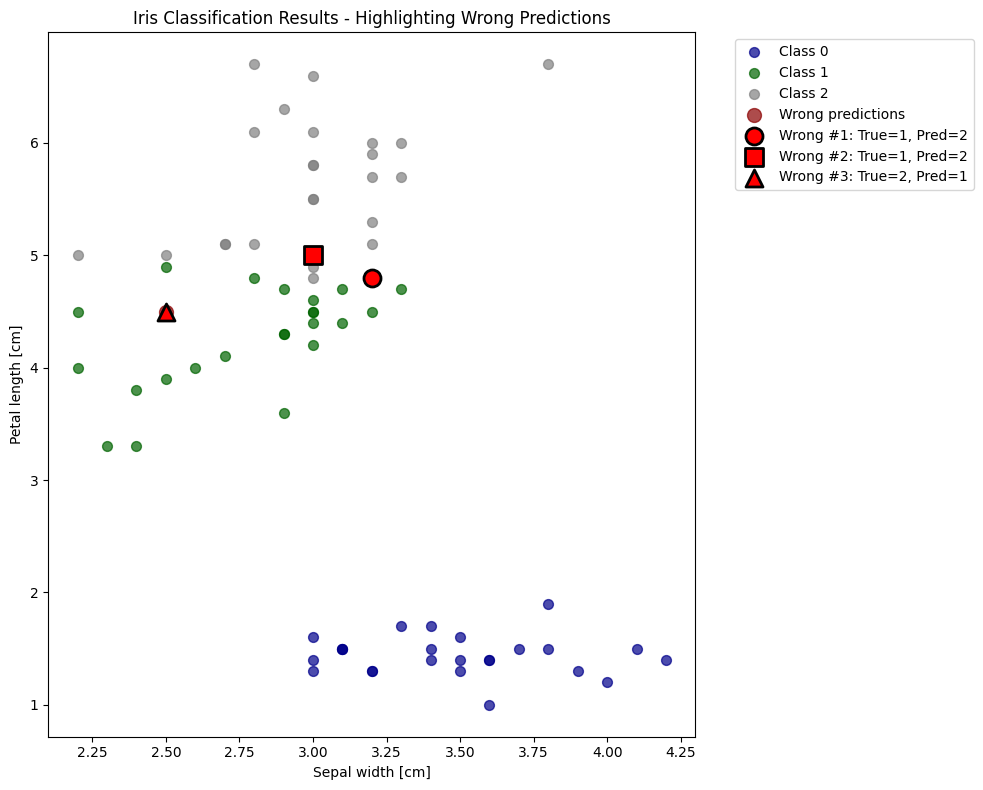


=== Analysis of Wrong Predictions ===
Reasons for misclassification:
1. Feature overlap: Classes 1 (Versicolor) and 2 (Virginica) have overlapping regions
2. Boundary ambiguity: Samples near class boundaries are harder to classify
3. Limited features: Using only 2 dimensions may not capture all discriminative information

Detailed analysis of first 3 wrong predictions:

Sample 44:
  Features (sepal width, petal length): [3.2 4.8]
  True class: 1, Predicted class: 2
  This sample lies in the overlapping region between classes 1 and 2

Sample 49:
  Features (sepal width, petal length): [3. 5.]
  True class: 1, Predicted class: 2
  This sample lies in the overlapping region between classes 1 and 2

Sample 60:
  Features (sepal width, petal length): [2.5 4.5]
  True class: 2, Predicted class: 1
  This sample lies in the overlapping region between classes 2 and 1


In [11]:
# Print true labels and predicted labels of wrong predictions
print("Wrong predictions analysis:")
print(f"Total wrong predictions: {len(incorrect_idx)}")
print(f"Indices of wrong predictions: {incorrect_idx}")

if len(incorrect_idx) >= 3:
    # Take first 3 wrong predictions
    first_3_wrong = incorrect_idx[:3]
    print(f"\nFirst 3 wrong predictions (indices): {first_3_wrong}")
    print("True labels vs Predicted labels:")
    for i, idx in enumerate(first_3_wrong):
        print(f"Sample {idx}: True={test_y[idx]}, Predicted={pred_y[idx]}")
else:
    print(f"Only {len(incorrect_idx)} wrong predictions available")
    first_3_wrong = incorrect_idx

# Modified scatterplot with different markers for the 3 wrong predictions
colors = ["darkblue", "darkgreen", "gray"]
markers = ['o', 's', '^']  # circle, square, triangle for the 3 wrong samples

plt.figure(figsize=(10, 8))

# Plot all test samples by class
for n, color in enumerate(colors):
    idx = np.where(test_y == n)[0]
    plt.scatter(test_X[idx, 1], test_X[idx, 2], color=color, 
               label="Class %s" % str(n), alpha=0.7, s=50)

# Highlight all wrong predictions in red
plt.scatter(test_X[incorrect_idx, 1], test_X[incorrect_idx, 2], 
           color="darkred", s=100, alpha=0.7, label="Wrong predictions")

# Highlight first 3 wrong predictions with different markers
if len(incorrect_idx) >= 3:
    for i, idx in enumerate(first_3_wrong):
        plt.scatter(test_X[idx, 1], test_X[idx, 2], 
                   color="red", marker=markers[i], s=150, 
                   label=f"Wrong #{i+1}: True={test_y[idx]}, Pred={pred_y[idx]}",
                   edgecolor='black', linewidth=2)

plt.xlabel('Sepal width [cm]')
plt.ylabel('Petal length [cm]')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Fixed: removed duplicate loc
plt.title("Iris Classification Results - Highlighting Wrong Predictions")
plt.tight_layout()
plt.show()

# Analysis of why the classifier made wrong predictions
print("\n=== Analysis of Wrong Predictions ===")
print("Reasons for misclassification:")
print("1. Feature overlap: Classes 1 (Versicolor) and 2 (Virginica) have overlapping regions")
print("2. Boundary ambiguity: Samples near class boundaries are harder to classify")
print("3. Limited features: Using only 2 dimensions may not capture all discriminative information")

if len(incorrect_idx) >= 3:
    print("\nDetailed analysis of first 3 wrong predictions:")
    for i, idx in enumerate(first_3_wrong):
        true_label = test_y[idx]
        pred_label = pred_y[idx]
        features = test_X[idx, [1, 2]]  # sepal width, petal length
        print(f"\nSample {idx}:")
        print(f"  Features (sepal width, petal length): {features}")
        print(f"  True class: {true_label}, Predicted class: {pred_label}")
        print(f"  This sample lies in the overlapping region between classes {true_label} and {pred_label}")

**Giải thích tại sao classifier đưa ra dự đoán sai:**

1. **Vùng chồng lấp (Feature overlap):** Các lớp 1 (Versicolor) và 2 (Virginica) có vùng chồng lấp trong không gian đặc trưng 2D mà chúng ta đang sử dụng.

2. **Ranh giới mơ hồ:** Các mẫu nằm gần ranh giới giữa các lớp rất khó phân loại chính xác, đặc biệt với thuật toán K-Nearest Neighbors.

3. **Giới hạn đặc trưng:** Chỉ sử dụng 2 trong 4 đặc trưng có thể không đủ để phân biệt hoàn toàn các lớp.

4. **Nhiễu dữ liệu:** Một số mẫu có thể có đặc trưng không điển hình cho lớp của chúng.

Class 1 samples in test set: 25
Class 2 samples in test set: 25


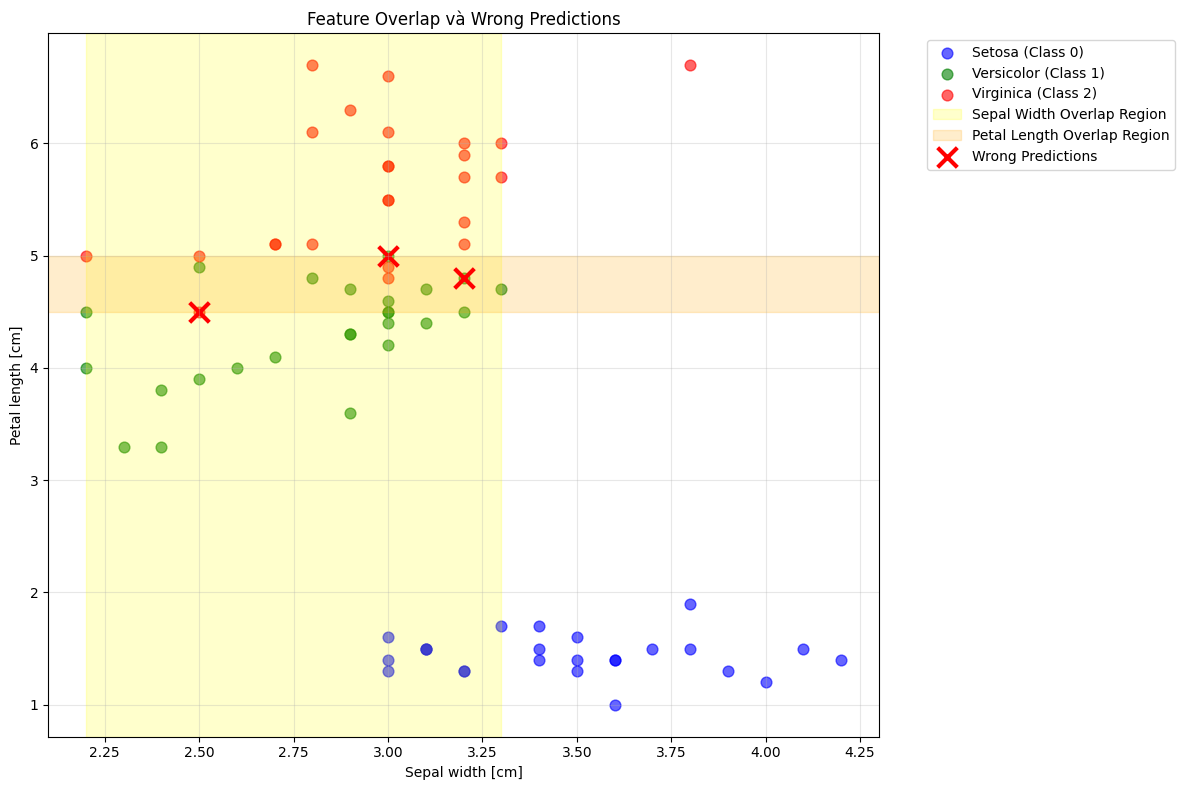

=== PHÂN TÍCH VÙNG CHỒNG LẤN ===
Class 1 (Versicolor) - Sepal width range: 2.20 - 3.30
Class 1 (Versicolor) - Petal length range: 3.30 - 5.00
Class 2 (Virginica) - Sepal width range: 2.20 - 3.80
Class 2 (Virginica) - Petal length range: 4.50 - 6.70

=== CHI TIẾT CÁC DỰ ĐOÁN SAI ===
Tổng số dự đoán sai: 3
Mẫu 44: Thực tế=1, Dự đoán=2, Sepal_width=3.20, Petal_length=4.80
Mẫu 49: Thực tế=1, Dự đoán=2, Sepal_width=3.00, Petal_length=5.00
Mẫu 60: Thực tế=2, Dự đoán=1, Sepal_width=2.50, Petal_length=4.50


In [13]:
# Code để hiển thị vùng chồng lấn rõ ràng hơn - FIXED VERSION
plt.figure(figsize=(12, 8))

# Plot từng class với transparency để thấy vùng chồng lấn
colors = ["blue", "green", "red"]
class_names = ["Setosa", "Versicolor", "Virginica"]

for n, (color, name) in enumerate(zip(colors, class_names)):
    idx = np.where(test_y == n)[0]
    if len(idx) > 0:  # Check if class exists in test data
        plt.scatter(test_X[idx, 1], test_X[idx, 2], 
                   color=color, alpha=0.6, s=60,
                   label=f"{name} (Class {n})")

# Tính toán vùng overlap giữa class 1 và 2
class1_idx = np.where(test_y == 1)[0]
class2_idx = np.where(test_y == 2)[0]

print(f"Class 1 samples in test set: {len(class1_idx)}")
print(f"Class 2 samples in test set: {len(class2_idx)}")

# Check if we have data for both classes
if len(class1_idx) > 0 and len(class2_idx) > 0:
    class1_data = test_X[class1_idx][:, [1, 2]]  # Fixed indexing
    class2_data = test_X[class2_idx][:, [1, 2]]  # Fixed indexing
    
    # Calculate actual overlap regions based on data
    class1_sepal_range = [class1_data[:, 0].min(), class1_data[:, 0].max()]
    class1_petal_range = [class1_data[:, 1].min(), class1_data[:, 1].max()]
    class2_sepal_range = [class2_data[:, 0].min(), class2_data[:, 0].max()]
    class2_petal_range = [class2_data[:, 1].min(), class2_data[:, 1].max()]
    
    # Find overlap regions
    sepal_overlap = [max(class1_sepal_range[0], class2_sepal_range[0]),
                     min(class1_sepal_range[1], class2_sepal_range[1])]
    petal_overlap = [max(class1_petal_range[0], class2_petal_range[0]),
                     min(class1_petal_range[1], class2_petal_range[1])]
    
    # Only highlight if there's actual overlap
    if sepal_overlap[0] < sepal_overlap[1]:
        plt.axvspan(sepal_overlap[0], sepal_overlap[1], alpha=0.2, color='yellow', 
                   label='Sepal Width Overlap Region')
    
    if petal_overlap[0] < petal_overlap[1]:
        plt.axhspan(petal_overlap[0], petal_overlap[1], alpha=0.2, color='orange', 
                   label='Petal Length Overlap Region')

# Highlight wrong predictions
if len(incorrect_idx) > 0:
    plt.scatter(test_X[incorrect_idx, 1], test_X[incorrect_idx, 2], 
               color="red", s=200, marker='x', linewidth=3,
               label="Wrong Predictions")

plt.xlabel('Sepal width [cm]')
plt.ylabel('Petal length [cm]')
plt.title('Feature Overlap và Wrong Predictions')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=== PHÂN TÍCH VÙNG CHỒNG LẤN ===")
if len(class1_idx) > 0:
    print(f"Class 1 (Versicolor) - Sepal width range: {test_X[class1_idx, 1].min():.2f} - {test_X[class1_idx, 1].max():.2f}")
    print(f"Class 1 (Versicolor) - Petal length range: {test_X[class1_idx, 2].min():.2f} - {test_X[class1_idx, 2].max():.2f}")
else:
    print("No Class 1 samples in test set")

if len(class2_idx) > 0:
    print(f"Class 2 (Virginica) - Sepal width range: {test_X[class2_idx, 1].min():.2f} - {test_X[class2_idx, 1].max():.2f}")
    print(f"Class 2 (Virginica) - Petal length range: {test_X[class2_idx, 2].min():.2f} - {test_X[class2_idx, 2].max():.2f}")
else:
    print("No Class 2 samples in test set")

# Additional analysis of wrong predictions
if len(incorrect_idx) > 0:
    print(f"\n=== CHI TIẾT CÁC DỰ ĐOÁN SAI ===")
    print(f"Tổng số dự đoán sai: {len(incorrect_idx)}")
    for i, idx in enumerate(incorrect_idx):
        print(f"Mẫu {idx}: Thực tế={test_y[idx]}, Dự đoán={pred_y[idx]}, "
              f"Sepal_width={test_X[idx, 1]:.2f}, Petal_length={test_X[idx, 2]:.2f}")

In [10]:
# %load solutions/04_wrong-predictions.py